✅ ¡Encontrada! La ruta exacta es: /content/drive/MyDrive/Cyclistic_Data
Archivos dentro: ['202505-divvy-tripdata.csv', '202506-divvy-tripdata.csv', '202507-divvy-tripdata.csv', '202508-divvy-tripdata.csv', '202509-divvy-tripdata.csv', '202510-divvy-tripdata.csv', '202511-divvy-tripdata.csv', '202512-divvy-tripdata.csv', '202601-divvy-tripdata.csv', '202602-divvy-tripdata.csv', '202603-divvy-tripdata.csv', '202604-divvy-tripdata.csv']
Cargando 12 archivos... ten paciencia, son muchos datos.
✅ ¡Todo cargado! Tienes un total de 5,697,455 filas listas para analizar.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5697455 entries, 0 to 5697454
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id  

/tmp/ipykernel_10685/736201956.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=promedios.index, y=promedios.values, palette='viridis')


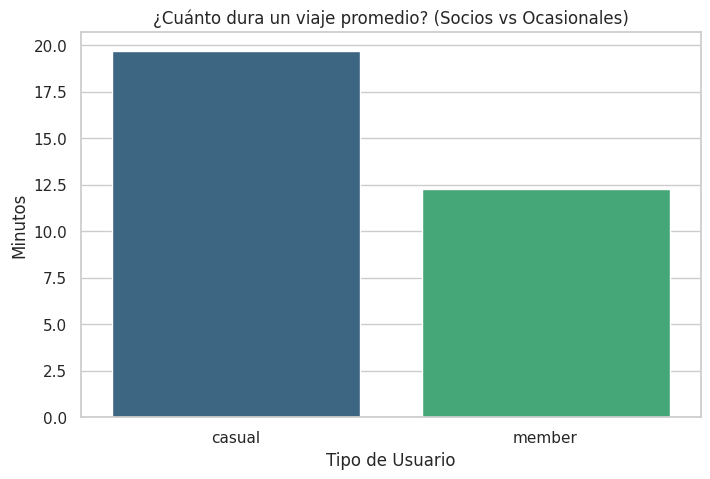

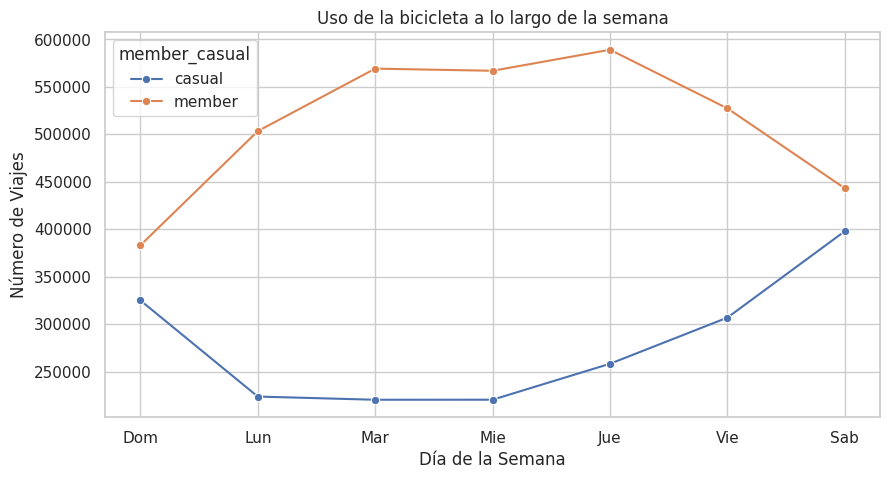

In [9]:
import os

# Buscamos la carpeta en todo tu Drive
def buscar_carpeta(nombre, ruta_inicio='/content/drive/MyDrive/'):
    for raiz, dirs, archivos in os.walk(ruta_inicio):
        if nombre in dirs:
            return os.path.join(raiz, nombre)
    return None

mi_ruta = buscar_carpeta('Cyclistic_Data')

if mi_ruta:
    print(f"✅ ¡Encontrada! La ruta exacta es: {mi_ruta}")
    cont = os.listdir(mi_ruta)
    print(f"Archivos dentro: {cont}")
else:
    print("❌ No la encuentro. Asegúrate de que el nombre en Drive es exactamente 'Cyclistic_Data'")

    import pandas as pd
import glob
import os

# Usamos la ruta que acabamos de encontrar
ruta_final = '/content/drive/MyDrive/Cyclistic_Data/'
archivos_csv = glob.glob(os.path.join(ruta_final, "*.csv"))

# Cargamos y unimos todos los archivos
print(f"Cargando {len(archivos_csv)} archivos... ten paciencia, son muchos datos.")
lista_df = [pd.read_csv(f) for f in archivos_csv]
df = pd.concat(lista_df, ignore_index=True)

print(f"✅ ¡Todo cargado! Tienes un total de {len(df):,} filas listas para analizar.")

# Vemos un resumen de las columnas
df.info()

# 1. Convertir las columnas de tiempo a formato fecha real
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

# 2. Calcular la duración del viaje (ride_length)
df['ride_length'] = df['ended_at'] - df['started_at']

# 3. Calcular el día de la semana (1=Domingo, 7=Sábado) como pide la guía
# dt.dayofweek da 0 para lunes, así que lo ajustamos:
df['day_of_week'] = ((df['started_at'].dt.dayofweek + 1) % 7) + 1

# 4. Limpiar datos erróneos: viajes de 0 segundos o negativos
filas_antes = len(df)
df = df[df['ride_length'] > pd.Timedelta(0)]
filas_despues = len(df)

print(f"Eliminamos {filas_antes - filas_despues} filas con duraciones negativas o cero.")
print(f"Ahora tienes {len(df):,} filas limpias.")

# Ver cómo han quedado las columnas nuevas
df[['started_at', 'ended_at', 'ride_length', 'day_of_week']].head()

# Creamos una columna en segundos para limpiar mejor
df['ride_length_seconds'] = df['ride_length'].dt.total_seconds()

# Mantenemos solo viajes de más de 60 segundos y menos de 24 horas
df_limpio = df[(df['ride_length_seconds'] > 60) & (df['ride_length_seconds'] < 86400)].copy()

print(f"Limpieza completada.")
print(f"Filas eliminadas por ser demasiado cortas o largas: {len(df) - len(df_limpio)}")
print(f"Filas finales para el análisis: {len(df_limpio):,}")

# 1. Duración media en minutos por tipo de usuario
print("--- 1. PROMEDIO DE VIAJE (Minutos) ---")
promedio = df_limpio.groupby('member_casual')['ride_length_seconds'].mean() / 60
print(promedio)

# 2. Número total de viajes por tipo de usuario
print("\n--- 2. TOTAL DE VIAJES ---")
total_viajes = df_limpio.groupby('member_casual')['ride_id'].count()
print(total_viajes)

# 3. Viajes por día de la semana (Para ver cuándo usan más la bici)
print("\n--- 3. VIAJES POR DÍA (1=Dom, 7=Sab) ---")
print(df_limpio.groupby(['member_casual', 'day_of_week'])['ride_id'].count())

import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo
sns.set_theme(style="whitegrid")

# 1. Gráfico de Barras: Duración Promedio
plt.figure(figsize=(8, 5))
promedios = df_limpio.groupby('member_casual')['ride_length_seconds'].mean() / 60
sns.barplot(x=promedios.index, y=promedios.values, palette='viridis')
plt.title('¿Cuánto dura un viaje promedio? (Socios vs Ocasionales)')
plt.ylabel('Minutos')
plt.xlabel('Tipo de Usuario')
plt.show()

# 2. Gráfico de Líneas: Viajes por día de la semana
plt.figure(figsize=(10, 5))
viajes_dia = df_limpio.groupby(['day_of_week', 'member_casual']).size().reset_index(name='total_viajes')
sns.lineplot(data=viajes_dia, x='day_of_week', y='total_viajes', hue='member_casual', marker='o')
plt.title('Uso de la bicicleta a lo largo de la semana')
plt.xticks(range(1, 8), ['Dom', 'Lun', 'Mar', 'Mie', 'Jue', 'Vie', 'Sab'])
plt.ylabel('Número de Viajes')
plt.xlabel('Día de la Semana')
plt.show()

